In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import (
    mcwf_dt_from_scales,
    omega_c,
    scaled_N_Gamma,
)
from common.utils.phases import default_three_phase_protocol
from parser.moments import MomentSeries, SimulationMetadata

%reload_ext autoreload
%autoreload 2

output_dir = repo_root / "output"

### Parameters

In [2]:
from solvers.mfe import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFESolverParameters

from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
)

# common fixed
Gamma = 1; num_snapshots=500
# param
dN = 0
Ni = [10,10]


Omega_factor = 0.1
delta_factor = 0.02
omega_i = [0.7]



# Model and parameters
Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)
#delta0 = 1
# protocol durations
T1 = 1000.0
T2 = 1000.0
T3 = 1000.0

phase_protocol = default_three_phase_protocol(
    durations=(T1, T2, T3),
    delta0=delta0,
    Omega0=Omega0,
)
simulation_metadata = SimulationMetadata(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phase_protocol=phase_protocol,
)

print(f"Omega0 = {Omega0}")
print(f"delta0 = {delta0}")

Omega0 = 2.0
delta0 = 0.4


### Homogeneous MFE

In [3]:

# moment initialization
h_mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)

# Define method parameters and solve using mean-field equations
h_mfe_parameters = MFESolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=[1.0,1.0],
    Gamma=simulation_metadata.Gamma,
    phase_protocol=simulation_metadata.phase_protocol,
)
h_mfe_result = solve_mfe(
    h_mfe_parameters,
    t_eval=h_mfe_moments.t,
)

# compute moments
h_mfe_moments.J = compute_mfe_j_moments(h_mfe_result)


### Inhomogeneous MFE

In [4]:

# moment initialization
inh_mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)

# Define method parameters and solve using mean-field equations
inh_mfe_parameters = MFESolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=simulation_metadata.omega_groups,
    Gamma=simulation_metadata.Gamma,
    phase_protocol=simulation_metadata.phase_protocol,
)
inh_mfe_result = solve_mfe(
    inh_mfe_parameters,
    t_eval=inh_mfe_moments.t,
)

# compute moments
inh_mfe_moments.J = compute_mfe_j_moments(inh_mfe_result)


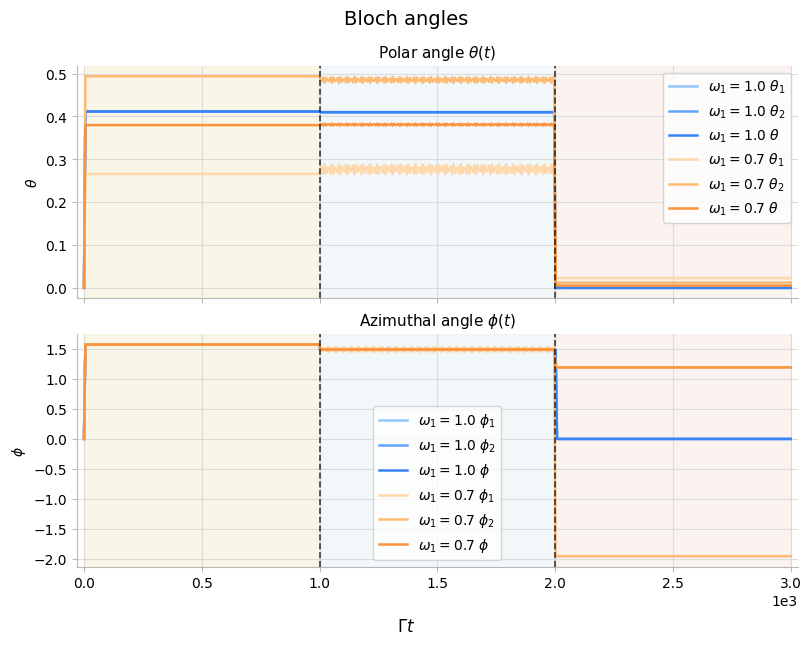

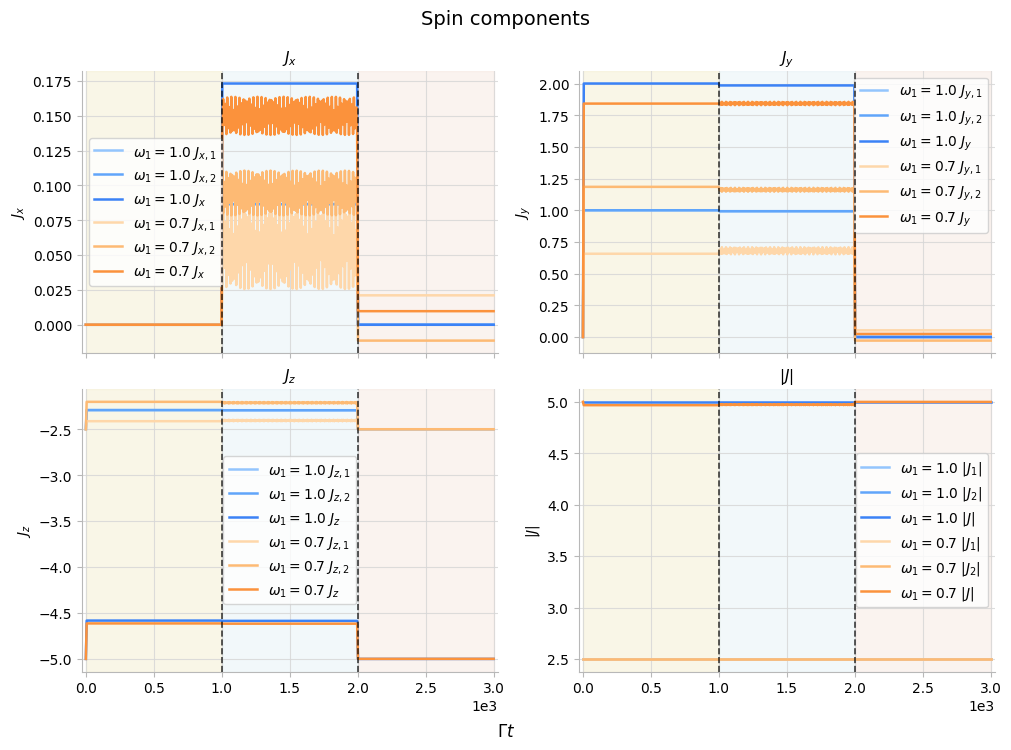

In [10]:

fig, axes = plot_bloch_angles(
    h_mfe_moments.J.t,
    h_mfe_moments.J.theta_groups,
    h_mfe_moments.J.phi_groups,
    phase_protocol=h_mfe_moments.metadata.phase_protocol,
    colour_family_index=0,
    #shade_index=3,
    linestyle="-",
)

fig, axes = plot_bloch_angles(
    inh_mfe_moments.J.t,
    inh_mfe_moments.J.theta_groups,
    inh_mfe_moments.J.phi_groups,
    phase_protocol=inh_mfe_moments.metadata.phase_protocol,
    colour_family_index=1,
    #shade_index=3,
    linestyle="-",
    axes=axes,
    output_path=f"{output_dir}/h_v_inh_mfe/angles"

)

fig, axes = plot_spin_components(
    h_mfe_moments.J.t,
    h_mfe_moments.J.x_groups,
    h_mfe_moments.J.y_groups,
    h_mfe_moments.J.z_groups,
    h_mfe_moments.J.length_groups,
    phase_protocol=h_mfe_moments.metadata.phase_protocol,
    colour_family_index=0,
    #shade_index=3,
    linestyle="-",
)

fig, axes = plot_spin_components(
    inh_mfe_moments.J.t,
    inh_mfe_moments.J.x_groups,
    inh_mfe_moments.J.y_groups,
    inh_mfe_moments.J.z_groups,
    inh_mfe_moments.J.length_groups,
    phase_protocol=inh_mfe_moments.metadata.phase_protocol,
    colour_family_index=1,
    #shade_index=3,
    linestyle="-",
    axes=axes,
    output_path=f"{output_dir}/h_v_inh_mfe/spins"
)

